# Análisis exploratorio de incidencia delictiva en México

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/delitos.csv')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

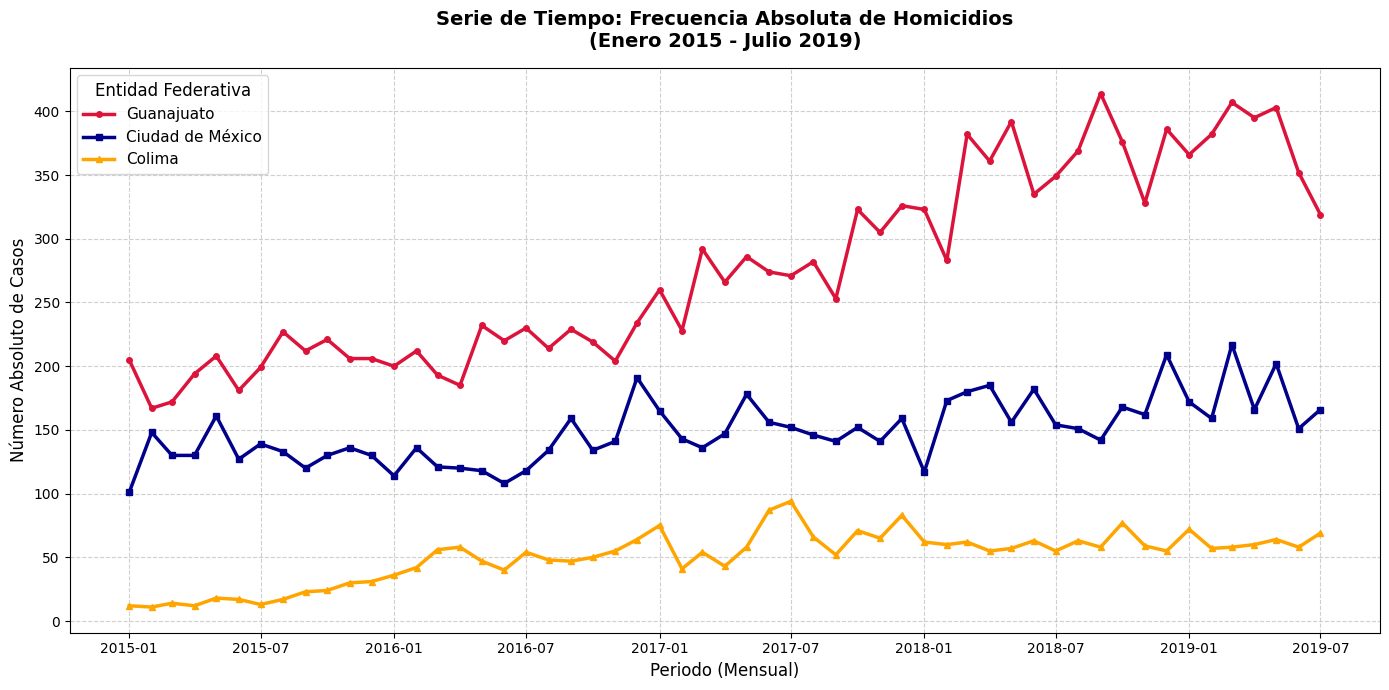

In [17]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')

estados_interes = ['Guanajuato', 'Colima', 'Ciudad de México']
df_filtrado = df_delitos[
    (df_delitos['tipo_de_delito'] == 'Homicidio') & 
    (df_delitos['entidad'].isin(estados_interes))
].copy()

df_filtrado['fecha'] = pd.to_datetime(df_filtrado['fecha'])

df_serie = df_filtrado.groupby([
    'fecha', 'anio', 'clave_ent', 'entidad', 'tipo_de_delito', 'nombre_mes'
])['frecuencia'].sum().reset_index()

df_serie = df_serie[(df_serie['fecha'] >= '2015-01-01') & (df_serie['fecha'] <= '2019-07-01')]

df_pivot = df_serie.pivot(index='fecha', columns='entidad', values='frecuencia')

plt.figure(figsize=(14, 7))
plt.plot(df_pivot.index, df_pivot['Guanajuato'], label='Guanajuato', color='crimson', linewidth=2.5, marker='o', markersize=4)
plt.plot(df_pivot.index, df_pivot['Ciudad de México'], label='Ciudad de México', color='darkblue', linewidth=2.5, marker='s', markersize=4)
plt.plot(df_pivot.index, df_pivot['Colima'], label='Colima', color='orange', linewidth=2.5, marker='^', markersize=4)

plt.title('Serie de Tiempo: Frecuencia Absoluta de Homicidios\n(Enero 2015 - Julio 2019)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periodo (Mensual)', fontsize=12)
plt.ylabel('Número Absoluto de Casos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Entidad Federativa', fontsize=11, title_fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [24]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')
total_colima_2018 = df_delitos[
    (df_delitos['tipo_de_delito'] == 'Homicidio') & 
    (df_delitos['entidad'] == 'Colima') & 
    (df_delitos['anio'] == 2018)
]['frecuencia'].sum()

print(f"Homicidios en Colima durante 2018: {int(total_colima_2018)}")

Homicidios en Colima durante 2018: 726


In [25]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')
total_robo_2019 = df_delitos[
    (df_delitos['tipo_de_delito'] == 'Robo') & 
    (df_delitos['anio'] == 2019)
]['frecuencia'].sum()

print(f"Casos de robo en 2019: {int(total_robo_2019)}")

Casos de robo en 2019: 766096


In [28]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')
suma_anual = df_delitos[
    df_delitos['tipo_de_delito'].isin(['Homicidio', 'Feminicidio'])
].groupby('anio')['frecuencia'].sum()

print("Suma anual de Homicidios y Feminicidios:")
print(suma_anual.astype(int))

Suma anual de Homicidios y Feminicidios:
anio
2015    31744
2016    36018
2017    42068
2018    45385
2019    45822
2020    44223
2021    44960
2022    43845
2023    42846
2024    22307
Name: frecuencia, dtype: int64


In [29]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')
df_feminicidios = df_delitos[df_delitos['tipo_de_delito'] == 'Feminicidio']

idx_max = df_feminicidios['frecuencia'].idxmax()
registro_max = df_feminicidios.loc[idx_max]

print(f"Mayor número de feminicidios mensuales ocurrió en:")
print(f"Año: {registro_max['anio']}, Mes: {registro_max['nombre_mes']}, Estado: {registro_max['entidad']} ({int(registro_max['frecuencia'])} casos)")

Mayor número de feminicidios mensuales ocurrió en:
Año: 2020, Mes: julio, Estado: México (19 casos)


In [30]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')
df_feminicidios = df_delitos[df_delitos['tipo_de_delito'] == 'Feminicidio']

acumulado_estado_anio = df_feminicidios.groupby(['anio', 'entidad'])['frecuencia'].sum().reset_index()
idx_max_anual = acumulado_estado_anio['frecuencia'].idxmax()
registro_max_anual = acumulado_estado_anio.loc[idx_max_anual]

print(f"El mayor acumulado anual ocurrió en el año {registro_max_anual['anio']} en el estado de {registro_max_anual['entidad']} con {int(registro_max_anual['frecuencia'])} casos.")

El mayor acumulado anual ocurrió en el año 2020 en el estado de México con 151 casos.


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

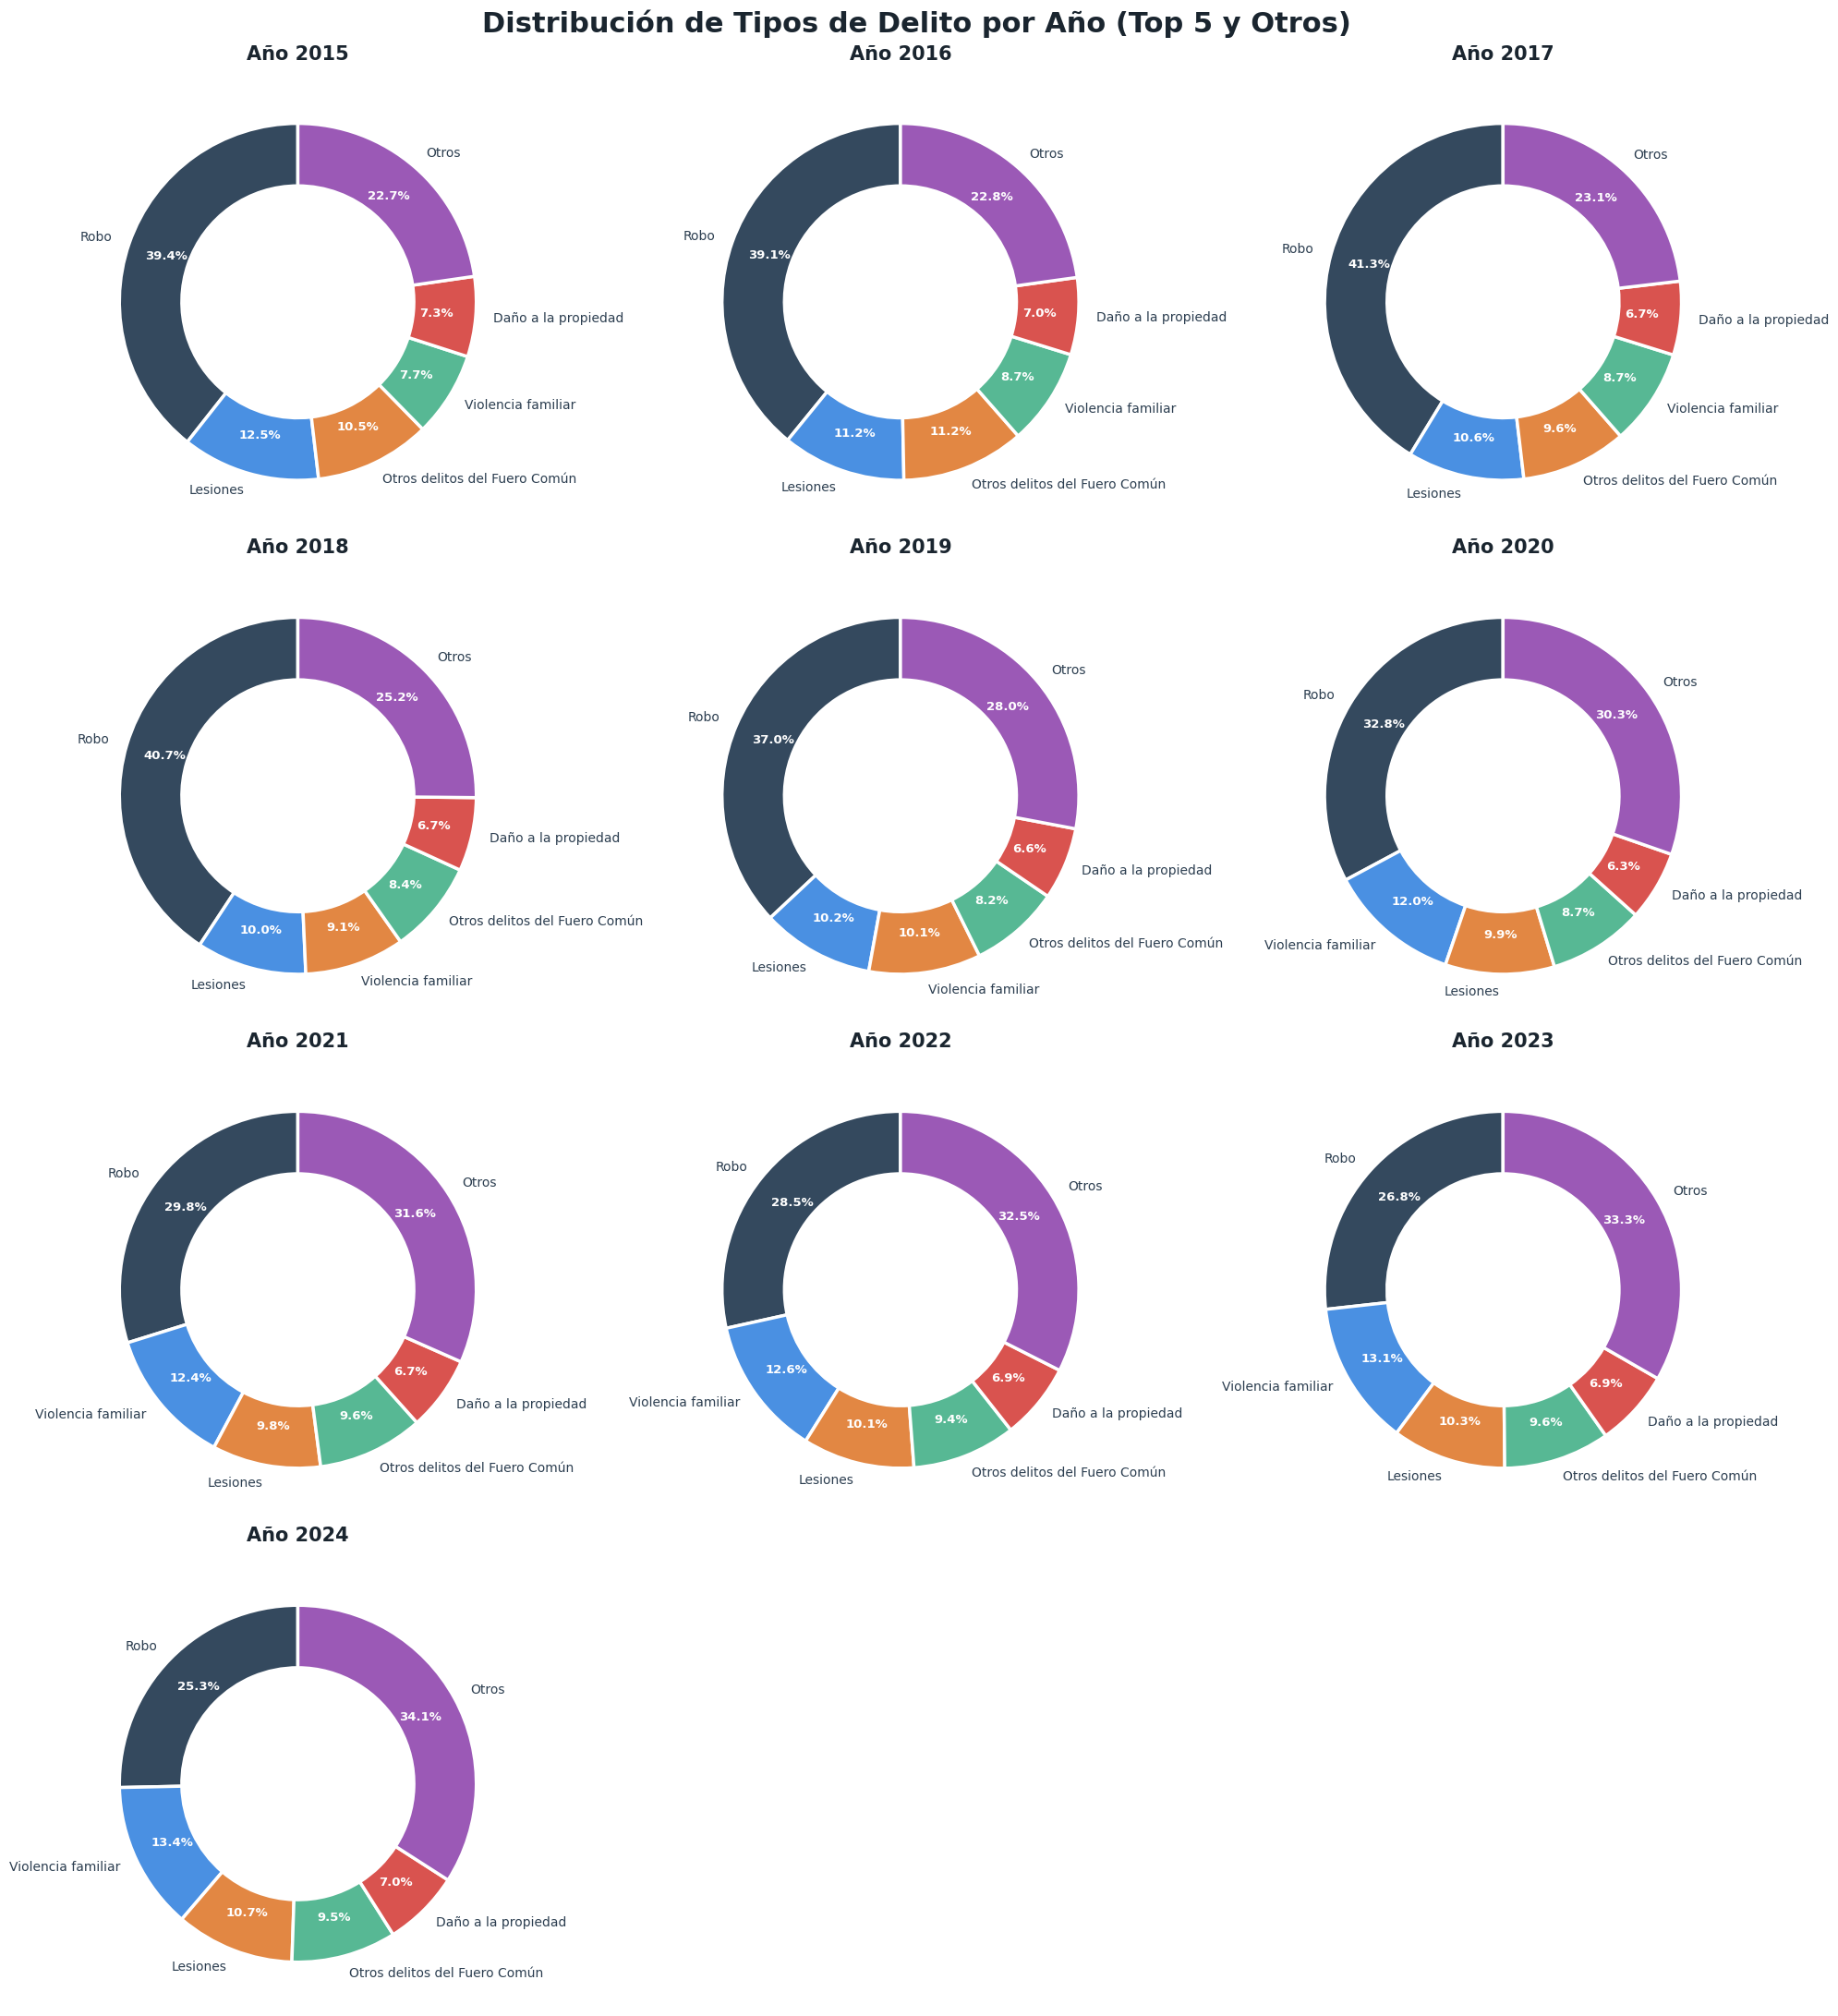

In [36]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')

df_agrupado = df_delitos.groupby(['anio', 'tipo_de_delito'])['frecuencia'].sum().reset_index()

anios = sorted(df_agrupado['anio'].unique())
n_anios = len(anios)

columnas_grid = 3
filas_grid = (n_anios + columnas_grid - 1) // columnas_grid

plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2C3E50'

fig, axes = plt.subplots(filas_grid, columnas_grid, figsize=(20, 5.5 * filas_grid))
axes = axes.flatten()

colores_modernos = ['#34495E', '#4A90E2', '#E28743', '#57B894', '#D9534F', '#9B59B6', '#F1C40F']

for i, anio in enumerate(anios):
    ax = axes[i]
    df_anio = df_agrupado[df_agrupado['anio'] == anio]
    df_anio = df_anio[df_anio['frecuencia'] > 0].sort_values(by='frecuencia', ascending=False)
    
    if len(df_anio) > 5:
        top_delitos = df_anio.iloc[:5].copy()
        otros_frecuencia = df_anio.iloc[5:]['frecuencia'].sum()
        otros_row = pd.DataFrame([{'anio': anio, 'tipo_de_delito': 'Otros', 'frecuencia': otros_frecuencia}])
        df_plot = pd.concat([top_delitos, otros_row], ignore_index=True)
    else:
        df_plot = df_anio

    wedges, texts, autotexts = ax.pie(
        df_plot['frecuencia'], 
        labels=df_plot['tipo_de_delito'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores_modernos[:len(df_plot)],
        pctdistance=0.78,
        wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2.5)
    )
    
    for autotext in autotexts:
        autotext.set_fontsize(9.5)
        autotext.set_weight('bold')
        autotext.set_color('#FFFFFF')
        
    for text in texts:
        text.set_fontsize(10)
        
    ax.set_title(f'Año {anio}', fontsize=15, fontweight='bold', pad=15, color='#1A252F')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de Tipos de Delito por Año (Top 5 y Otros)', fontsize=22, fontweight='bold', y=0.99, color='#1A252F')
plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [37]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


In [ ]:
df_delitos = pd.read_csv('data/delitos.csv', encoding='utf-8')

poblacion_2015 = {
    'Aguascalientes': 1312544, 'Baja California': 3315766, 'Baja California Sur': 712029,
    'Campeche': 899931, 'Coahuila de Zaragoza': 2954915, 'Colima': 711235,
    'Chiapas': 5217908, 'Chihuahua': 3556574, 'Ciudad de México': 8918653,
    'Durango': 1754754, 'Guanajuato': 5853677, 'Guerrero': 3533251,
    'Hidalgo': 2858359, 'Jalisco': 7844830, 'México': 16187608,
    'Michoacán de Ocampo': 4584471, 'Morelos': 1903811, 'Nayarit': 1181050,
    'Nuevo León': 5119504, 'Oaxaca': 3967889, 'Puebla': 6168883,
    'Querétaro': 2038372, 'Quintana Roo': 1501562, 'San Luis Potosí': 2717820,
    'Sinaloa': 2966321, 'Sonora': 2850330, 'Tabasco': 2395272,
    'Tamaulipas': 3441698, 'Tlaxcala': 1272847, 'Veracruz de Ignacio de la Llave': 8112505,
    'Yucatán': 2097175, 'Zacatecas': 1579209
}

df_delitos['poblacion'] = df_delitos['entidad'].map(poblacion_2015)

df_delitos['tasa'] = (df_delitos['frecuencia'] / df_delitos['poblacion']) * 100000

df_delitos['tasa_anualizada'] = df_delitos['tasa'] * 12

print(df_delitos[['anio', 'entidad', 'tipo_de_delito', 'frecuencia', 'tasa', 'tasa_anualizada']].head())

   anio         entidad tipo_de_delito  frecuencia      tasa  tasa_anualizada
0  2015  Aguascalientes         Aborto         0.0  0.000000         0.000000
1  2015  Aguascalientes         Aborto         0.0  0.000000         0.000000
2  2015  Aguascalientes         Aborto         0.0  0.000000         0.000000
3  2015  Aguascalientes         Aborto         0.0  0.000000         0.000000
4  2015  Aguascalientes         Aborto         3.0  0.228564         2.742765
